# Deep Learning - Homework 3

## Exploring Network Depth on Regression Performance on theCalifornia Housing Dataset

## Comparison of Regression using SLP vs shallow MLP vs deep MLP

### Marianna Kanellaki
### S-001081

In [176]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow import keras
import pandas as pd
import numpy as np
import seaborn as sns

#### Data loading

In [177]:
data = fetch_california_housing(as_frame=True)
data

X = data.data
y = data.target

# Basic inspection
print(X.head())
print("Shape:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Shape: (20640, 8)


#### Data split & scaling

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [179]:
# reproducability
keras.utils.set_random_seed(42)

#### Single Layer Perceptron

In [180]:
def build_slp():
    model = keras.Sequential([
        layers.Input(shape=(8,)),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",
        metrics=["mae"]
    )
    return model

slp = build_slp()
slp.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_165 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

#### Shallow Multi Layer Perceptron

In [181]:
def build_shallow_model():
    model = keras.Sequential([
        layers.Input(shape=(8,)),          # input layer (8 features)
        layers.Dense(16, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        
        layers.Dense(1, activation="relu")   # regression
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",
        metrics=["mae"]
    )
    return model

mlp_shallow = build_shallow_model()
mlp_shallow.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_166 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,233 (4.82 KB)

 Non-trainable params: 0 (0.00 B)

#### Deep Multi Layer Perceptron

In [182]:
def build_deep_model():
    model = keras.Sequential([
        layers.Input(shape=(8,)),          # input layer (8 features)
        layers.Dense(16, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(168, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="relu")   # regression
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",
        metrics=["mae"]
    )
    return model

mlp_deep = build_deep_model()
mlp_deep.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_170 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 168)            │        10,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 64)             │        10,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,161 (106.10 KB)

 Trainable params: 27,161 (106.10 KB)

 Non-trainable params: 0 (0.00 B)

In [183]:
models = {
    "Single-Layer Perceptron": slp,
    "Shallow MLP": mlp_shallow,
    "Deep MLP": mlp_deep
}

#### Training & Evaluation

In [184]:
results = []
histories = {}

for name, model in models.items():
    
    # train
    histories[name] = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=0
    )
    
    # get predictions
    y_tr_pred = model.predict(X_train).flatten()
    y_te_pred = model.predict(X_test).flatten()
    
    # calculate regression metrics
    tr_mse = mean_squared_error(y_train, y_tr_pred)
    te_mse = mean_squared_error(y_test, y_te_pred)
    tr_mae = mean_absolute_error(y_train, y_tr_pred)
    te_mae = mean_absolute_error(y_test, y_te_pred)
    
    metrics = {
        "Model": name,
        "Train MSE": mean_squared_error(y_train, y_tr_pred),
        "Test MSE": mean_squared_error(y_test, y_te_pred),
        "Train MAE": mean_absolute_error(y_train, y_tr_pred),
        "Test MAE": mean_absolute_error(y_test, y_te_pred),
        "R2 Score": r2_score(y_test, y_te_pred)
    }
    results.append(metrics)

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step


#### Comparison

In [185]:
df_results = pd.DataFrame(results)
df_results

,Model,Train MSE,Test MSE,Train MAE,Test MAE,R2 Score
0,Single-Layer Perceptron,0.525255,0.552811,0.531152,0.534241,0.578139
1,Shallow MLP,0.266599,0.302115,0.354778,0.370587,0.769450
2,Deep MLP,0.264119,0.291196,0.346816,0.362562,0.777782


The results demonstrate how adding hidden layers impacts the model's ability to learn and generalize. The Single-Layer Perceptron (SLP) underfits with high error rates and an $R^2$ score of just 0.578. It is too shallow to capture the non-linear patterns in the dataset. The Shallow MLP provides a significant performance boost, raising the $R^2$ score to 0.769 and significantly lowering the error rates. This model generalizes well. The Deep MLP achieves the highest accuracy ($R^2$ = 0.777), improving slightly over the shallow model.

#### Plots

##### Predictions VS Ground Truth

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step


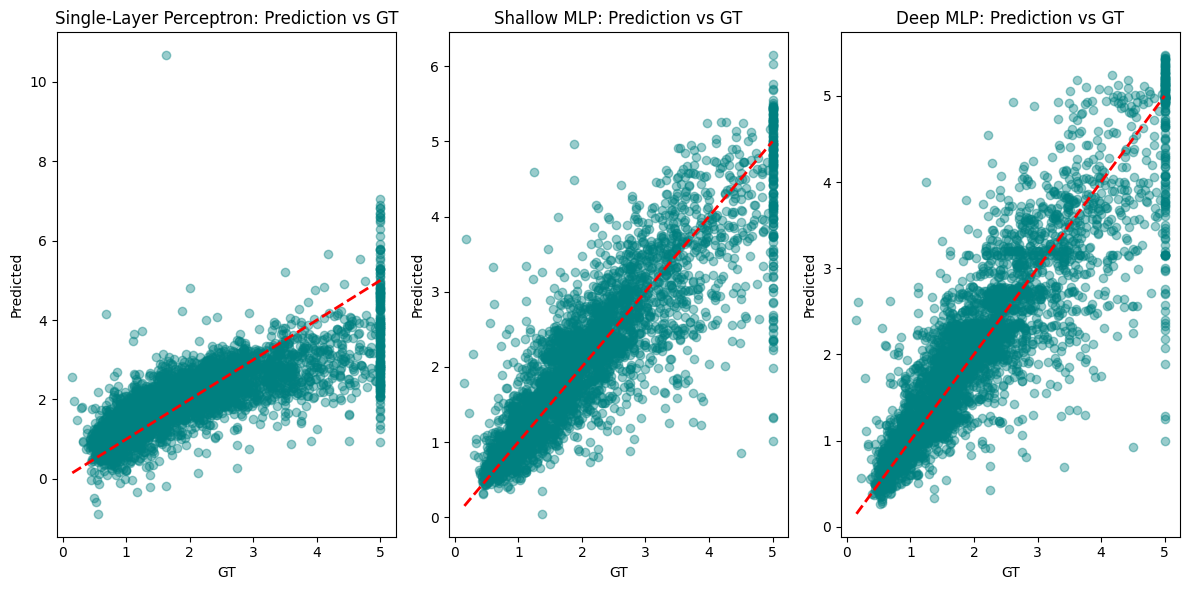

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, (name, model) in enumerate(models.items()):
    y_te_pred = model.predict(X_test).flatten()
    residuals = y_test - y_te_pred
    
    axes[i].scatter(y_test, y_te_pred, alpha=0.4, color='teal')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(f"{name}: Prediction vs GT")
    axes[i].set_xlabel("GT")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

These scatter plots provide clear visual evidence of how architectural depth influences the model's performance. 

The Single-Layer Perceptron shows a visual representation of underfitting, with the predictions failing to follow the red diagonal, particularly at higher ground truth values. Its linear nature prevents it from understanding the relationships in the data. 

The Shallow MLP shows a significant improvement, with the points clustering much more tightly around the ideal diagonal. This indicates that the model has successfully learned the non-linear patterns in the data, leading to a much more accurate and reliable set of predictions.

The Deep MLP looks very similar to the shallow model, with points tracking the diagonal line closely. However, there is no major visual difference between the two. While the Deep MLP is technically more complex, it doesn't provide a visible boost over the shallow MLP, suggesting that the extra layers are not providing significant new insights for this specific dataset.

##### Residual Distribution

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step


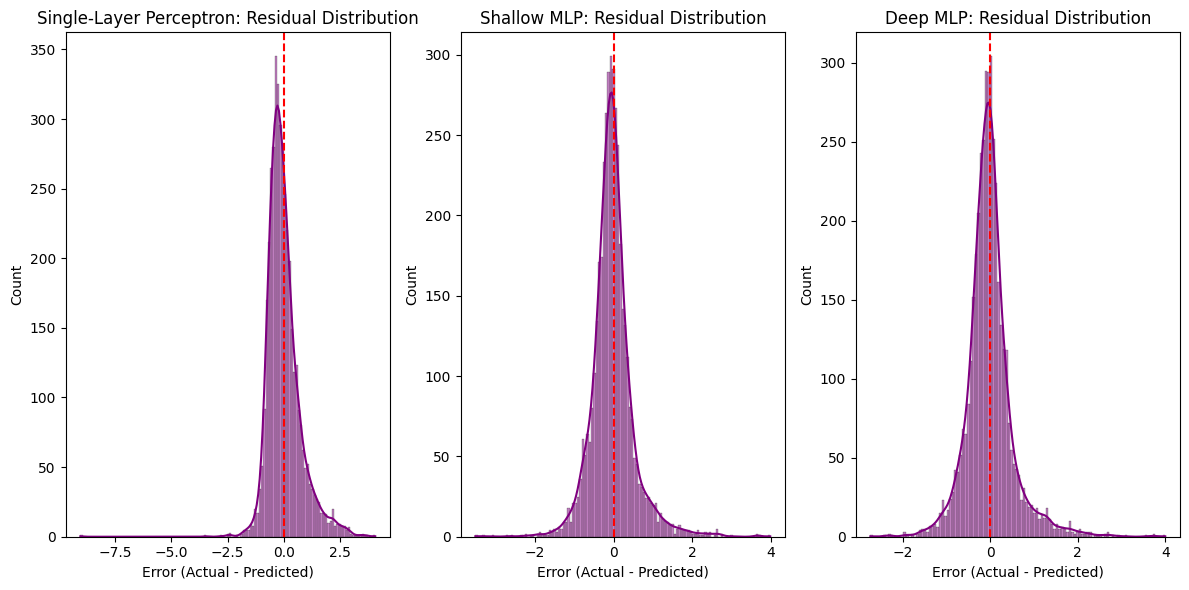

In [187]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for i, (name, model) in enumerate(models.items()):
    y_te_pred = model.predict(X_test).flatten()
    residuals = y_test - y_te_pred
    
    sns.histplot(residuals, kde=True, ax=axes[i], color='purple')
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_title(f"{name}: Residual Distribution")
    axes[i].set_xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

The residual distribution plots further highlight the differences in model performance.

The Single-Layer Perceptron struggles to map the dataset accurately. While its errors are centered near zero, the base of the distribution is wide, indicating that the model frequently makes errors. The model seems to frequently over-predict (bigger negative range on x-axis), demonstrating a high-bias. The SLP is clearly overfitting.

The Shallow MLP resolves the SLP's limitations by introducing hidden layers. This model's errors are a symmetrical narrow curve centered on the zero line. The tall peak indicates that the majority of its errors are extremely small. This concentrated distribution confirms that the model has successfully captured the underlying data patterns and provides reliable predictions.

The Deep MLP looks almost identical to the Shallow MLP, maintaining the same narrow bell shape and central peak height. This visual similarity confirms that the added depth does not meaningfully improve the model's precision for this dataset.

##### Learning Curves

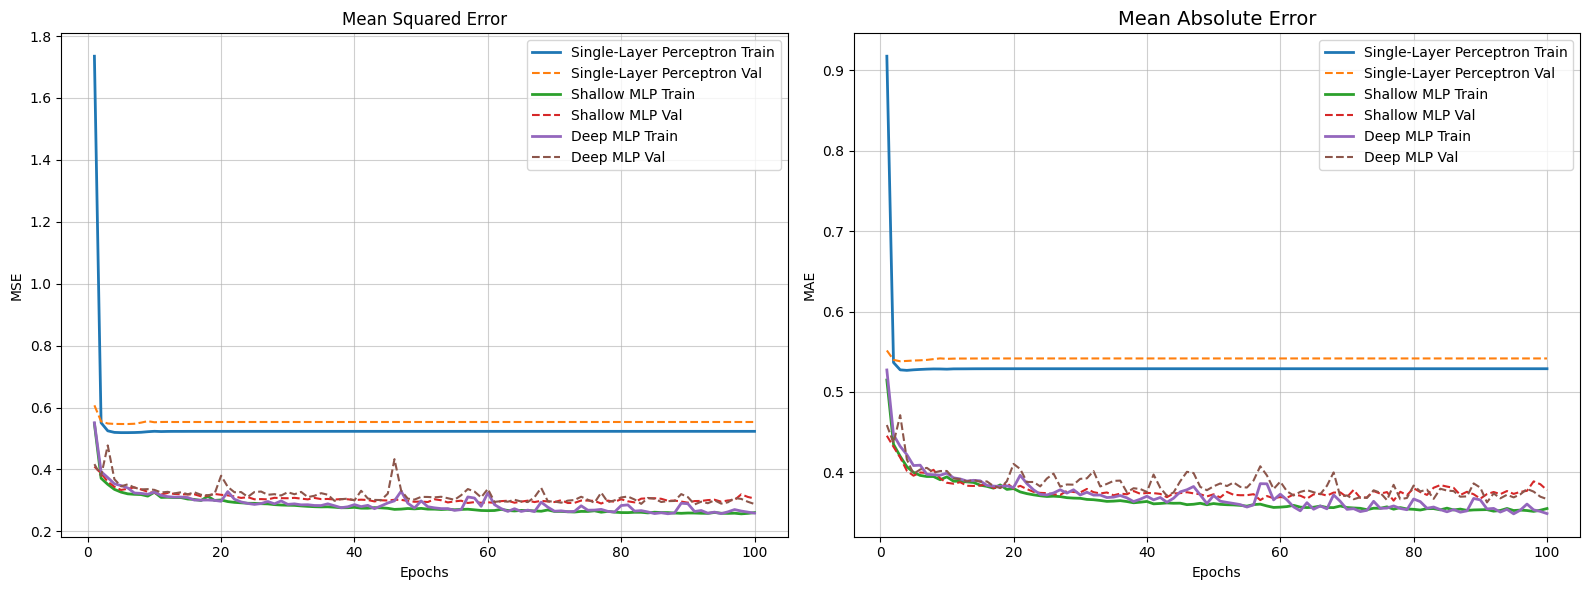

In [188]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(histories):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, (name, history) in enumerate(histories.items()):
        train_loss = history.history['loss']
        val_loss = history.history['val_loss']
        train_mae = history.history['mae']
        val_mae = history.history['val_mae']
        
        epochs = range(1, len(train_loss) + 1)

        # MSE
        ax1.plot(epochs, train_loss, label=f'{name} Train', lw=2)
        ax1.plot(epochs, val_loss, label=f'{name} Val', linestyle='--')
        
        # MAE
        ax2.plot(epochs, train_mae, label=f'{name} Train', lw=2)
        ax2.plot(epochs, val_mae, label=f'{name} Val', linestyle='--')

    ax1.set_title('Mean Squared Error')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MSE')
    ax1.grid(True, alpha=0.6)
    ax1.legend(loc='upper right')

    ax2.set_title('Mean Absolute Error', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MAE')
    ax2.grid(True, alpha=0.6)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Run the plot
plot_learning_curves(histories)

The learning curves plot the training and validation errors over 100 epochs, providing a dynamic view of how each model learns and visually confirming their generalization capabilities.

Looking at the Single-Layer Perceptron, the curves drop rapidly but plateau almost immediately at a high error level. While the gap between training and validation is small, the model cannot push the error any lower. This plateau shows the underfitting. The linear architecture quickly learns everything it can, hits its capacity limit, and stops improving.

The Shallow MLP demonstrates a highly effective learning process. Both training and validation errors descend smoothly to a significantly lower level than the SLP. The training and validation lines remain tightly coupled throughout the entire 100 epochs, confirming that the model is learning generalizable features without memorizing the training data.

The Deep MLP's curves converge to almost the same final error floor as the Shallow MLP. Furthermore, while the training and validation gaps remain relatively tight, the Deep MLP's validation curve exhibits more fluctuations compared to the shallow model. This instability suggests that the network's excessive depth introduces unnecessary variance into the training process, confirming that the added complexity provides no significant benefit for this dataset.

#### Conclusion

This comparative analysis demonstrates that while increasing architectural depth generally tends to yield better results, excessive model complexity can lead to degraded generalization.

The Single-Layer Perceptron overfitted, proving mathematically insufficient for this dataset. Its linearity resulted in high bias, high overall error, and an inability to learn the underlying distribution of the data, as evidenced by its scattered predictions, high residual distribution, and learning curve plateau.

The Deep MLP achieved the highest accuracy on the dataset ($R^2 = 0.775$), but the improvement over the shallow model was negligible. The residual distributions were nearly identical, and the learning curves converged to the same performance floor. The added architectural depth failed to extract any meaningful new patterns from the data, meaning its increased computational cost is unjustified.

The Shallow MLP is the optimal choice for this dataset. By introducing a moderate level of non-linearity, it surpassed the SLP's performance while capturing the non-linear relationships within the data to achieve an $R^2$ of 0.769. It maintained tightly coupled learning curves and a concentrated, symmetrical error distribution. It shows the best balance of the performance and computational cost trade-off.